In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../../../")
from config.label_matchers import matchers

### Load the data:

In [2]:
projects = ["bootstrap", "DECA", "docker", "tensorflow", "vscode"]
labels = list(matchers["issue_intention"].values())

In [12]:
data = []
for project in projects:
    for label in labels:
        with open(f"./{project}/{label}", "r", encoding="utf-8", errors="ignore") as file:
            for line in file:
                data.append([
                    project,
                    line.strip(),
                    label
                ])

df = pd.DataFrame(data, columns=["project", "text", "label"]).reset_index(names=["id"])

In [13]:
print("Number of instances:", df.shape[0])

Number of instances: 6375


In [14]:
df.sample(5)

,id,project,text,label
37,37,bootstrap,I really really like the different layout poss...,aspect evaluation
5644,5644,vscode,For once it's not as bad as you think and then...,aspect evaluation
288,288,bootstrap,There's only three classes: one to handle mont...,information giving
4786,4786,tensorflow,Thank you for your question.,others
5265,5265,tensorflow,"But, run example failed with following kernel ...",problem discovery


In [15]:
matcher = {v: k for (k, v) in matchers["issue_intention"].items()}
df["label"] = df["label"].replace(matcher).astype(int)

/tmp/ipykernel_346224/1362085671.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"] = df["label"].replace(matcher).astype(int)


### Clean the data:

In [16]:
print("Number of missing texts:", df["text"].isnull().sum())

Number of missing texts: 0


In [17]:
print("Number of missing labels:", df["label"].isnull().sum())

Number of missing labels: 0


In [18]:
print(f"Number of duplicated texts: {df["text"].duplicated().sum()} ({df["text"].duplicated().sum()/df.shape[0]:.2%})")

Number of duplicated texts: 218 (3.42%)


### Analyze distributions:

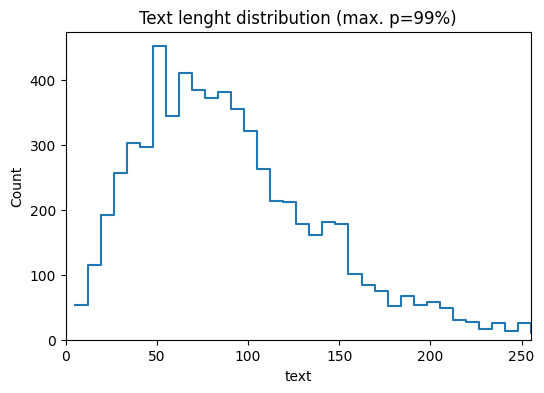

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(df["text"].str.len(), element="step", fill=False)
plt.xlim([
    0,
    df["text"].str.len().quantile(.99)
])
plt.title("Text lenght distribution (max. p=99%)")
plt.show()

In [20]:
df["label"].value_counts(dropna=False, normalize=True).round(2)

label
2    0.23
3    0.19
5    0.15
0    0.13
6    0.12
1    0.11
4    0.06
Name: proportion, dtype: float64

### Persist datasets:

In [22]:
df[["id", "project", "text", "label"]].to_parquet("./issue_intention.parquet", index=False)

In [23]:
print("Number of instances in the persisted dataset:", df.shape[0])

Number of instances in the persisted dataset: 6375
